# Analyse du trafic web

TP d'analyse de données — exploration, segmentation et cohortes.

Données : `data/processed/trafic_nettoye.csv` (2000 sessions, 7 colonnes).

## 1. Chargement et contrôle des données

On charge le CSV et on vérifie que tout est ok (dimensions, valeurs manquantes, doublons).

In [ ]:
# Installation des dépendances
# Depuis la racine du projet : pip install -r requirements.txt Ou dans le notebook :
%pip install -q -r ../requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# chemin vers le dataset
DATA_PATH = Path("../data/processed/trafic_nettoye.csv")

# charge les données dans un dataframe
df = pd.read_csv(DATA_PATH)

df.head()

,page_views,session_duration,bounce_rate,traffic_source,time_on_page,previous_visits,conversion_rate
0,5,11.051381,0.230652,Organic,3.890460,3,1.0
1,4,3.429316,0.391001,Social,8.478174,0,1.0
2,4,1.621052,0.397986,Organic,9.636170,2,1.0
3,5,3.629279,0.180458,Organic,2.071925,3,1.0
4,5,4.235843,0.291541,Paid,1.960654,5,1.0


In [4]:
# dimensions du dataframe
print(f"Dimensions : {df.shape}")
if df.shape != (2000, 7):
    print("Attention : shape différente de (2000, 7)")

# types et info
print("\nTypes :")
print(df.dtypes)
df.info()

# valeurs manquantes
nulls = df.isnull().sum()
print(f"\nValeurs manquantes :\n{nulls}")
if nulls.sum() > 0:
    print("Il y a des valeurs manquantes à traiter")

# doublons
n_doublons = df.duplicated().sum()
print(f"\nDoublons : {n_doublons}")

# sources de trafic
print(f"\nSources ({df['traffic_source'].nunique()}) : {sorted(df['traffic_source'].unique())}")

Dimensions : (2000, 7)

Types :
page_views            int64
session_duration    float64
bounce_rate         float64
traffic_source          str
time_on_page        float64
previous_visits       int64
conversion_rate     float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   page_views        2000 non-null   int64  
 1   session_duration  2000 non-null   float64
 2   bounce_rate       2000 non-null   float64
 3   traffic_source    2000 non-null   str    
 4   time_on_page      2000 non-null   float64
 5   previous_visits   2000 non-null   int64  
 6   conversion_rate   2000 non-null   float64
dtypes: float64(4), int64(2), str(1)
memory usage: 109.5 KB

Valeurs manquantes :
page_views          0
session_duration    0
bounce_rate         0
traffic_source      0
time_on_page        0
previous_visits     0
conversion_rate     0
dtyp

### Bilan

- 2000 lignes, 7 colonnes
- Pas de valeurs manquantes ni de doublons
- 6 variables numériques + `traffic_source` (Direct, Organic, Paid, Referral, Social)

**Note :** il n'y a pas de date dans les données. Pour la partie cohortes, on utilisera `previous_visits` (nombre de visites passées) à la place.

In [5]:
# résumé statistique des colonnes numériques
df.describe()

,page_views,session_duration,bounce_rate,time_on_page,previous_visits,conversion_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.950500,3.022045,0.284767,4.027439,1.978500,0.982065
std,2.183903,3.104518,0.159781,2.887422,1.432852,0.065680
min,0.000000,0.003613,0.007868,0.068515,0.000000,0.343665
25%,3.000000,0.815828,0.161986,1.935037,1.000000,1.000000
50%,5.000000,1.993983,0.266375,3.315316,2.000000,1.000000
75%,6.000000,4.197569,0.388551,5.414627,3.000000,1.000000
max,14.000000,20.290516,0.844939,24.796182,9.000000,1.000000


## 2. Exploration globale des données

On regarde les distributions des variables et la répartition des sources de trafic.

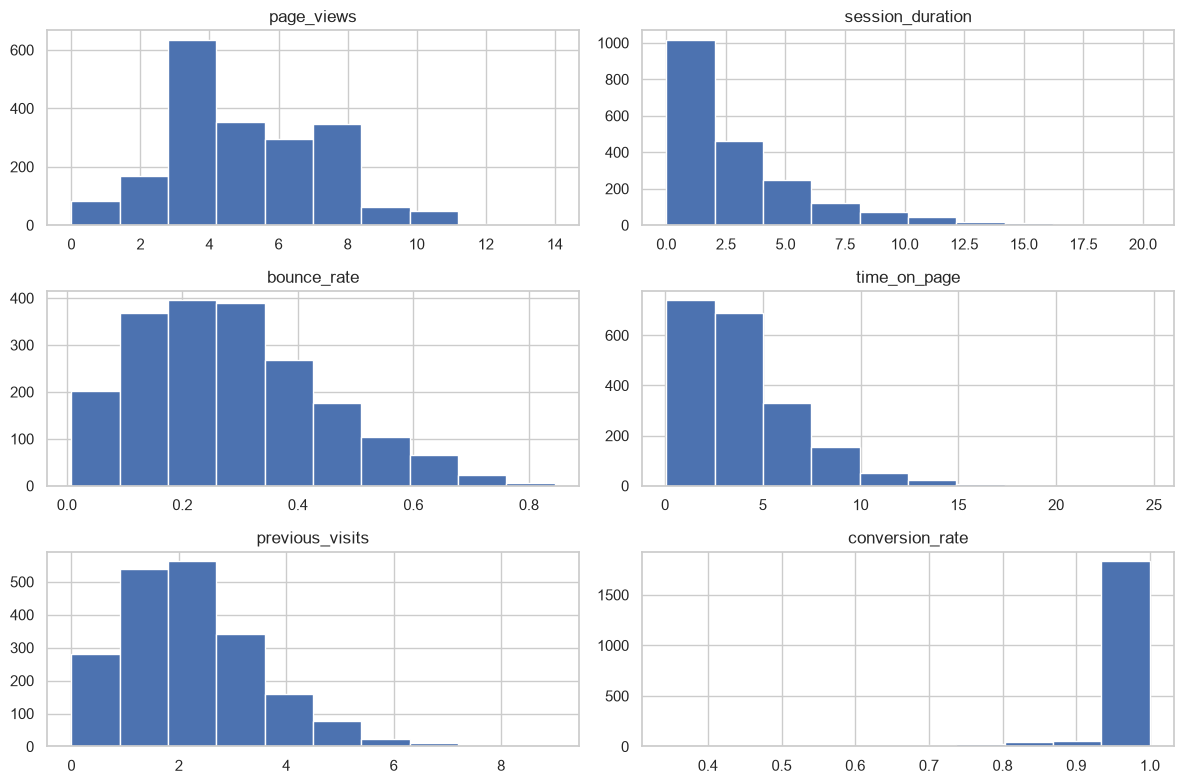

In [6]:
# histogrammes des variables numériques
cols_num = ["page_views", "session_duration", "bounce_rate", "time_on_page", "previous_visits", "conversion_rate"]
df[cols_num].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

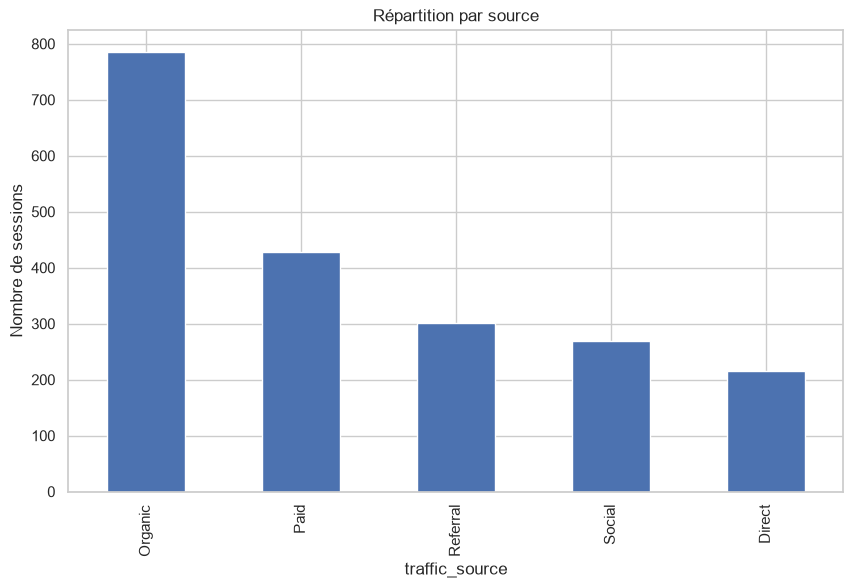

traffic_source
Organic     786
Paid        428
Referral    301
Social      269
Direct      216
Name: count, dtype: int64


In [7]:
# répartition par source de trafic
df["traffic_source"].value_counts().plot(kind="bar", title="Répartition par source")
plt.ylabel("Nombre de sessions")
plt.show()

print(df["traffic_source"].value_counts())

### Ce qu'on observe

- **Organic** est la source la plus fréquente.
- La durée de session varie beaucoup (certaines sessions très courtes).
- Le rebond moyen tourne autour de 0,3.


## 3. Analyse par segments

### 3.1 Par source de trafic

On calcule la moyenne de chaque métrique par source de trafic.

In [10]:
# moyennes par source
segments_source = df.groupby("traffic_source").agg({
    "page_views": "mean",
    "session_duration": "mean",
    "bounce_rate": "mean",
    "time_on_page": "mean",
    "previous_visits": "mean",
    "conversion_rate": "mean",
}).round(3)

segments_source

,page_views,session_duration,bounce_rate,time_on_page,previous_visits,conversion_rate
traffic_source,,,,,,
Direct,4.963,2.692,0.285,3.949,2.074,0.979
Organic,5.025,3.104,0.282,3.978,1.985,0.982
Paid,4.944,2.943,0.296,4.087,2.035,0.979
Referral,4.983,3.125,0.266,3.985,1.944,0.988
Social,4.695,3.057,0.296,4.188,1.833,0.983


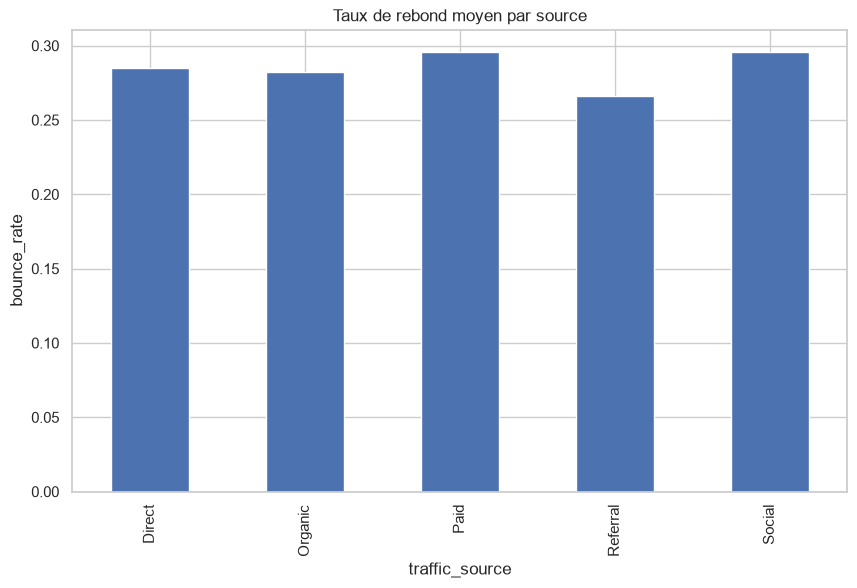

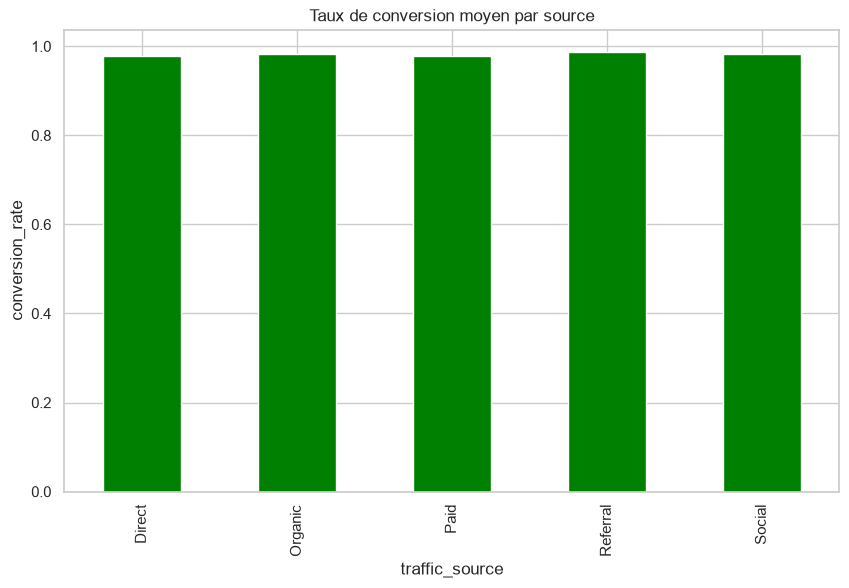

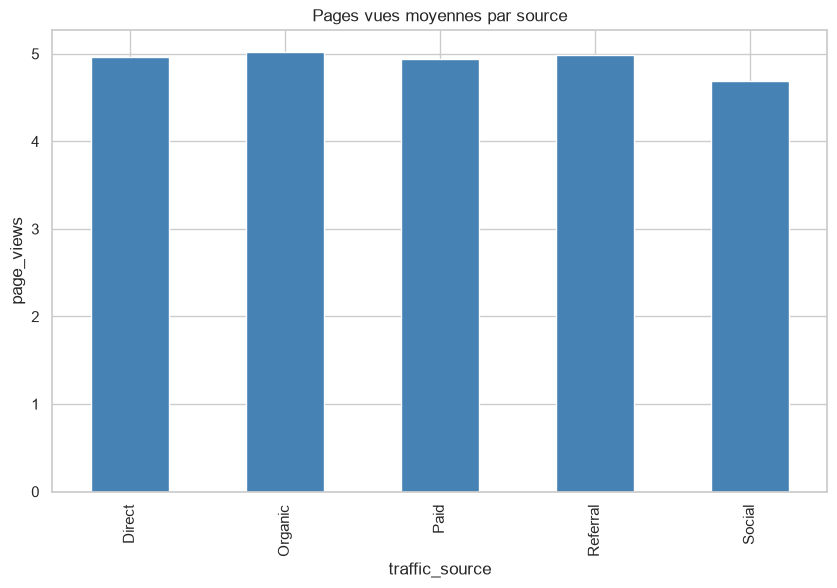

In [11]:
# rebond par source
segments_source["bounce_rate"].plot(kind="bar", title="Taux de rebond moyen par source")
plt.ylabel("bounce_rate")
plt.show()

# conversion par source
segments_source["conversion_rate"].plot(kind="bar", title="Taux de conversion moyen par source", color="green")
plt.ylabel("conversion_rate")
plt.show()

# pages vues par source
segments_source["page_views"].plot(kind="bar", title="Pages vues moyennes par source", color="steelblue")
plt.ylabel("page_views")
plt.show()

### 3.2 Nouveau vs récurrent

- **Nouveau** : `previous_visits == 0`
- **Récurrent** : au moins 1 visite antérieure

In [12]:
# création du segment
df["type_visiteur"] = "Récurrent"
df.loc[df["previous_visits"] == 0, "type_visiteur"] = "Nouveau"

df["type_visiteur"].value_counts()

type_visiteur
Récurrent    1718
Nouveau       282
Name: count, dtype: int64

In [13]:
# comparaison Nouveau vs Récurrent
df.groupby("type_visiteur").agg({
    "page_views": "mean",
    "bounce_rate": "mean",
    "conversion_rate": "mean",
}).round(3)

,page_views,bounce_rate,conversion_rate
type_visiteur,,,
Nouveau,4.979,0.284,0.968
Récurrent,4.946,0.285,0.984


In [14]:
# croisement type visiteur × source
df.groupby(["type_visiteur", "traffic_source"]).agg({
    "page_views": "mean",
    "bounce_rate": "mean",
    "conversion_rate": "mean",
}).round(3)

page_views  bounce_rate  conversion_rate
type_visiteur traffic_source                                          
Nouveau       Direct               4.676        0.294            0.970
              Organic              5.066        0.259            0.965
              Paid                 5.349        0.326            0.960
              Referral             5.136        0.278            0.977
              Social               4.577        0.297            0.969
Récurrent     Direct               5.022        0.283            0.980
              Organic              5.019        0.285            0.985
              Paid                 4.899        0.293            0.981
              Referral             4.957        0.264            0.990
              Social               4.724        0.296            0.986

### 3.3 Engagement et rebond

- **Engagement** : tertiles de `page_views` → Faible / Moyen / Fort
- **Rebond** : Bas (< 0,2) / Moyen (0,2–0,4) / Haut (≥ 0,4)

In [15]:
# niveau d'engagement (3 groupes égaux)
df["niveau_engagement"] = pd.qcut(df["page_views"], q=3, labels=["Faible", "Moyen", "Fort"])

# niveau de rebond (seuils fixes)
df["niveau_rebond"] = "Moyen"
df.loc[df["bounce_rate"] < 0.2, "niveau_rebond"] = "Bas"
df.loc[df["bounce_rate"] >= 0.4, "niveau_rebond"] = "Haut"

print(df["niveau_engagement"].value_counts())
print()
print(df["niveau_rebond"].value_counts())

niveau_engagement
Faible    888
Moyen     650
Fort      462
Name: count, dtype: int64

niveau_rebond
Moyen    859
Bas      687
Haut     454
Name: count, dtype: int64


In [16]:
# métriques par niveau d'engagement
df.groupby("niveau_engagement").agg({
    "page_views": "mean",
    "bounce_rate": "mean",
    "conversion_rate": "mean",
}).round(3)

,page_views,bounce_rate,conversion_rate
niveau_engagement,,,
Faible,3.005,0.280,0.974
Moyen,5.455,0.282,0.986
Fort,7.981,0.297,0.992


In [17]:
# métriques par niveau de rebond
df.groupby("niveau_rebond").agg({
    "page_views": "mean",
    "bounce_rate": "mean",
    "conversion_rate": "mean",
}).round(3)

,page_views,bounce_rate,conversion_rate
niveau_rebond,,,
Bas,4.869,0.121,0.982
Haut,5.051,0.516,0.975
Moyen,4.963,0.293,0.986


### Ce qu'on observe (segments)

- **Referral** a le meilleur rebond et la meilleure conversion.
- **Paid** et **Social** rebondissent plus.
- Les visiteurs **Récurrents** convertissent mieux que les **Nouveaux**.
- Plus l'engagement est fort, plus la conversion monte.

## 4. Analyse par cohortes

Pas de date dans les données, donc on groupe par fidélité (`previous_visits`).

### 4.1 Cohortes de fidélité

- **Nouveau** : `previous_visits == 0`
- **Occasionnel** : 1 ou 2 visites passées
- **Régulier** : 3 ou 4
- **Fidèle** : 5 et plus

In [18]:
# création de la colonne cohorte
df["cohorte"] = "Fidèle"
df.loc[df["previous_visits"] == 0, "cohorte"] = "Nouveau"
df.loc[df["previous_visits"].isin([1, 2]), "cohorte"] = "Occasionnel"
df.loc[df["previous_visits"].isin([3, 4]), "cohorte"] = "Régulier"

df["cohorte"].value_counts()

cohorte
Occasionnel    1102
Régulier        501
Nouveau         282
Fidèle          115
Name: count, dtype: int64

In [19]:
# moyennes par cohorte
cohortes_fidelite = df.groupby("cohorte").agg({
    "page_views": "mean",
    "session_duration": "mean",
    "bounce_rate": "mean",
    "time_on_page": "mean",
    "previous_visits": "mean",
    "conversion_rate": "mean",
}).round(3)

cohortes_fidelite

,page_views,session_duration,bounce_rate,time_on_page,previous_visits,conversion_rate
cohorte,,,,,,
Fidèle,5.122,2.802,0.252,3.853,5.470,0.995
Nouveau,4.979,3.154,0.284,3.966,0.000,0.968
Occasionnel,4.893,3.028,0.287,4.137,1.511,0.981
Régulier,5.022,2.986,0.289,3.862,3.319,0.989


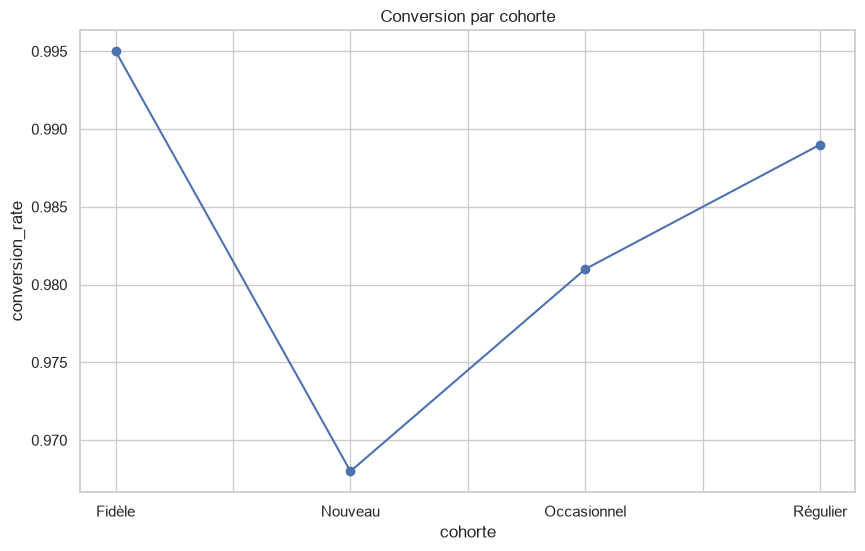

In [20]:
cohortes_fidelite["conversion_rate"].plot(kind="line", marker="o", title="Conversion par cohorte")
plt.ylabel("conversion_rate")
plt.show()

### 4.2 Cohorte × Source

On croise la cohorte et la source de trafic pour voir d'où viennent les nouveaux visiteurs et comment évolue la conversion.

In [21]:
# croisement cohorte × source
matrice_cohorte_source = df.groupby(["cohorte", "traffic_source"]).agg({
    "page_views": "mean",
    "session_duration": "mean",
    "bounce_rate": "mean",
    "time_on_page": "mean",
    "previous_visits": "mean",
    "conversion_rate": "mean",
}).round(3)

matrice_cohorte_source

page_views  session_duration  bounce_rate  \
cohorte     traffic_source                                              
Fidèle      Direct               4.562             2.779        0.250   
            Organic              5.432             2.953        0.233   
            Paid                 4.636             3.469        0.332   
            Referral             5.053             2.055        0.224   
            Social               5.643             2.318        0.227   
Nouveau     Direct               4.676             2.968        0.294   
            Organic              5.066             3.127        0.259   
            Paid                 5.349             3.012        0.326   
            Referral             5.136             3.390        0.278   
            Social               4.577             3.260        0.297   
Occasionnel Direct               5.029             2.576        0.285   
            Organic              4.904             3.148        0.286   
            Paid                 4.968             2.893        0.282   
            Referral             4.856             3.130        0.282   
            Social               4.674             3.101        0.304   
Régulier    Direct               5.131             2.695        0.288   
            Organic              5.180             3.030        0.295   
            Paid                 4.791             2.925        0.310   
            Referral             5.169             3.238        0.234   
            Social               4.627             2.948        0.294   

                            time_on_page  previous_visits  conversion_rate  
cohorte     traffic_source                                                  
Fidèle      Direct                 5.117            5.500            0.990  
            Organic                3.884            5.409            0.993  
            Paid                   3.062            5.364            0.996  
            Referral               4.192            5.526            1.000  
            Social                 3.091            5.714            1.000  
Nouveau     Direct                 4.119            0.000            0.970  
            Organic                4.009            0.000            0.965  
            Paid                   4.202            0.000            0.960  
            Referral               3.148            0.000            0.977  
            Social                 4.268            0.000            0.969  
Occasionnel Direct                 4.049            1.578            0.977  
            Organic                4.034            1.507            0.982  
            Paid                   4.233            1.534            0.978  
            Referral               4.110            1.461            0.985  
            Social                 4.370            1.493            0.981  
Régulier    Direct                 3.373            3.262            0.984  
            Organic                3.859            3.325            0.989  
            Paid                   3.911            3.318            0.986  
            Referral               4.153            3.324            0.998  
            Social                 3.936            3.356            0.993

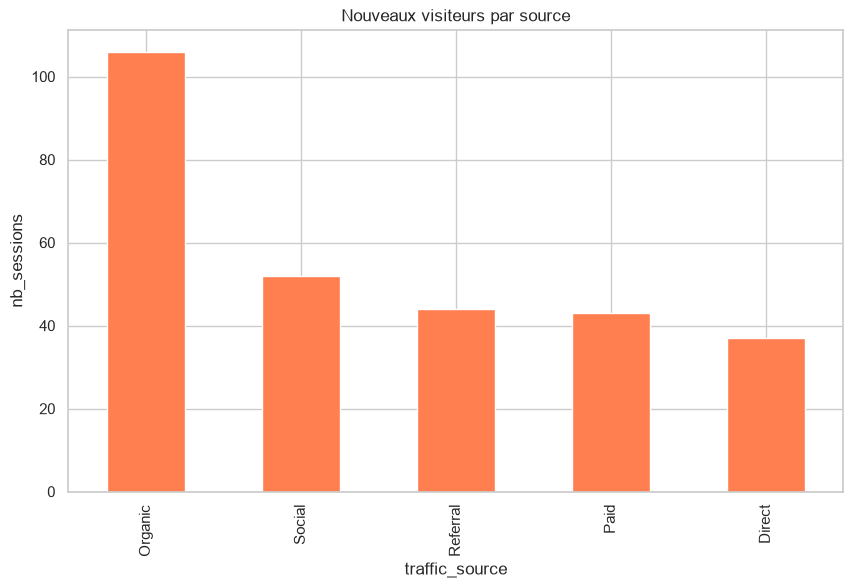

In [22]:
# nouveaux visiteurs par source
df[df["cohorte"] == "Nouveau"]["traffic_source"].value_counts().plot(
    kind="bar", title="Nouveaux visiteurs par source", color="coral"
)
plt.ylabel("nb_sessions")
plt.show()

### Ce qu'on observe (cohortes)

- La conversion augmente quand le visiteur revient plus souvent.
- **Organic** amène le plus de nouveaux visiteurs.
- **Referral** reste performant à tous les niveaux de fidélité.

**À creuser :** est-ce que Paid vaut le coup malgré un rebond plus élevé ? Il faudrait le coût par clic pour trancher.

## 5. Synthèse et export

Récap de ce qu'on a trouvé + export des tableaux pour Tableau / Power BI.

### Principaux résultats

1. **Organic** est le canal principal (~40 % des sessions).
2. **Referral** performe le mieux (rebond bas, conversion haute).
3. **Paid** et **Social** ont un rebond plus élevé — à surveiller.
4. Les **nouveaux visiteurs** convertissent moins bien que les récurrents.
5. Plus un visiteur revient, plus il convertit (cohortes de fidélité).

In [ ]:
# export des 3 tableaux pour la suite (Tableau / Power BI)
segments_source.reset_index().to_csv("../data/processed/segments_par_source.csv", index=False)
cohortes_fidelite.reset_index().to_csv("../data/processed/cohortes_par_fidelite.csv", index=False)
print("Fichiers exportés dans data/processed/")

Fichiers exportés dans data/processed/
